In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


   square_footage          price
0            1360  221931.841921
1            1794  278596.226894
2            1630  259014.984952
3            1595  252724.966959
4            2138  303452.511648
Training samples: 80
Testing samples: 20

Intercept (b): 51529.93
Coefficient (m): 119.38
Equation: price = 119.38 * square_footage + 51529.93

--- Model Evaluation ---
MAE:  12451.24
MSE:  205289067.37
RMSE: 14327.91
R²:   0.9778

Predicted price for a 2000 sqft house: $290,287.83


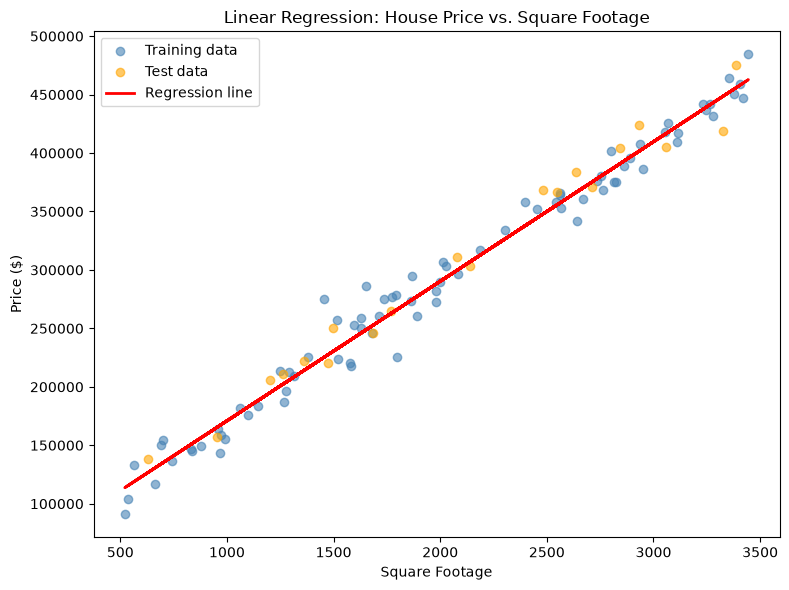

In [2]:

# ------------------------------------------------------------
# 1. Create / Load Data
# ------------------------------------------------------------
# Example: predicting house price based on square footage
np.random.seed(42)
square_footage = np.random.randint(500, 3500, 100)
# price = base + (price per sqft * sqft) + some noise
price = 50000 + (square_footage * 120) + np.random.normal(0, 15000, 100)

df = pd.DataFrame({"square_footage": square_footage, "price": price})

print(df.head())

# ------------------------------------------------------------
# 2. Split into Features (X) and Target (y)
# ------------------------------------------------------------
X = df[["square_footage"]]  # Features must be 2D (DataFrame or 2D array)
y = df["price"]  # Target can be 1D (Series or array)

# ------------------------------------------------------------
# 3. Split into Training and Test Sets
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# ------------------------------------------------------------
# 4. Create and Train the Model
# ------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------------------------
# 5. Inspect the Learned Parameters
# ------------------------------------------------------------
print(f"\nIntercept (b): {model.intercept_:.2f}")
print(f"Coefficient (m): {model.coef_[0]:.2f}")
print(
    f"Equation: price = {model.coef_[0]:.2f} * square_footage + {model.intercept_:.2f}"
)

# ------------------------------------------------------------
# 6. Make Predictions on Test Data
# ------------------------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------------------------
# 7. Evaluate the Model
# ------------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# ------------------------------------------------------------
# 8. Predict on New Data
# ------------------------------------------------------------
new_house = pd.DataFrame({"square_footage": [2000]})
predicted_price = model.predict(new_house)
print(f"\nPredicted price for a 2000 sqft house: ${predicted_price[0]:,.2f}")

# ------------------------------------------------------------
# 9. Visualize the Regression Line
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color="steelblue", alpha=0.6, label="Training data")
plt.scatter(X_test, y_test, color="orange", alpha=0.6, label="Test data")
plt.plot(X, model.predict(X), color="red", linewidth=2, label="Regression line")
plt.xlabel("Square Footage")
plt.ylabel("Price ($)")
plt.title("Linear Regression: House Price vs. Square Footage")
plt.legend()
plt.tight_layout()
plt.savefig("linear_regression_plot.png")
plt.show()
